# Case Study: LayerWiseSubset vs GlobalSubset Selection Analysis

This notebook generates the case study figures showing:
1. **Score magnitude** by layer type × transformer block
2. **Rank correlation with GlobalSubset** by layer type × transformer block

Data comes from the case study trainer (`analyze_selection.py`), which runs standard training while simultaneously computing LayerWiseSubset and GlobalSubset scores at each step.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from scipy.stats import spearmanr

# Match SFT/result.ipynb style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Layer type definitions
LAYER_TYPES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
TYPE_LABELS = {'q_proj': 'Q', 'k_proj': 'K', 'v_proj': 'V', 'o_proj': 'O',
               'gate_proj': 'Gate', 'up_proj': 'Up', 'down_proj': 'Down'}
type_colors = {
    'q_proj': '#E41A1C', 'k_proj': '#FF7F00', 'v_proj': '#FFD700',
    'o_proj': '#984EA3', 'gate_proj': '#377EB8', 'up_proj': '#4DAF4A',
    'down_proj': '#A65628',
}
attn_markers = {'q_proj': 'o', 'k_proj': 's', 'v_proj': '^', 'o_proj': 'v'}
mlp_markers = {'gate_proj': 'D', 'up_proj': 'P', 'down_proj': '*'}
all_markers = {**attn_markers, **mlp_markers}

save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

In [3]:
def classify_layers(layer_names):
    info = {}
    for i, name in enumerate(layer_names):
        block = -1
        parts = name.split('.')
        for j, p in enumerate(parts):
            if p == 'layers' and j + 1 < len(parts):
                block = int(parts[j + 1])
                break
        ltype = 'lm_head' if name == 'lm_head' else 'unknown'
        for t in LAYER_TYPES:
            if t in name:
                ltype = t
                break
        info[i] = {'block': block, 'type': ltype}
    return info


def load_data(path):
    with open(path) as f:
        data = json.load(f)
    layer_info = classify_layers(data['metadata']['layer_names'])
    batch_size = data['metadata']['train_batch_size']
    num_blocks = max(li['block'] for li in layer_info.values() if li['block'] >= 0) + 1

    block_type_abs = {b: {t: [] for t in LAYER_TYPES} for b in range(num_blocks)}
    block_type_spearman = {b: {t: [] for t in LAYER_TYPES} for b in range(num_blocks)}

    for sd in data['steps']:
        subset_scores = np.array(sd['subset']['selection']['scores'])
        for layer in sd['layer_wise_subset']['layers']:
            li = layer['layer_idx']
            scores = layer.get('scores', [])
            if not scores or len(scores) != batch_size:
                continue
            s = np.array(scores)
            info = layer_info[li]
            if info['type'] not in LAYER_TYPES or info['block'] < 0:
                continue
            block_type_abs[info['block']][info['type']].append(np.mean(np.abs(s)))
            rho, _ = spearmanr(s, subset_scores)
            block_type_spearman[info['block']][info['type']].append(rho)

    return {
        'block_type_abs': block_type_abs,
        'block_type_spearman': block_type_spearman,
        'num_blocks': num_blocks,
        'n_steps': len(data['steps']),
        'batch_size': batch_size,
    }


def style_ax(ax):
    ax.grid(True, alpha=0.3, linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)

## Load data

Selection records from case study runs matching the main SFT experiment configs.

In [4]:
repo_root = Path(os.environ.get('DRPT_REPO_ROOT', Path.cwd())).resolve()
if 'DRPT_REPO_ROOT' not in os.environ:
    repo_root = next((p for p in (repo_root, *repo_root.parents) if (p / 'SFT').is_dir()), repo_root)
runs_dir = Path(os.environ.get('DRPT_RUNS_DIR', repo_root / 'SFT' / 'runs'))
SEEDS = [2, 22, 42, 62, 82]

# Final 4 settings × 5 seeds. Recipe: full-parameter, lr=1e-5, linear+warmup_ratio=0.03+wd=0.
SETTINGS = [
    ('alpaca_samsum',    'p0.4',   '0.4'),
    ('less_tydiqa',      'p0.005', '0.005'),
    ('triviaqa_nq_open', 'p0.05',  '0.05'),
    ('less_squad',       'p0.005', '0.005'),
]


def merge_records(records):
    """Combine per-seed records into one by extending the score lists.

    `block_type_abs[b][t]` and `block_type_spearman[b][t]` are lists of
    per-step scalars. Concatenating across seeds gives the union of all
    observations (more samples → tighter percentile bands in the figures).
    """
    if not records:
        return None
    head = records[0]
    num_blocks = head['num_blocks']
    batch_size = head['batch_size']
    out_abs = {b: {t: [] for t in head['block_type_abs'][b]} for b in range(num_blocks)}
    out_rho = {b: {t: [] for t in head['block_type_spearman'][b]} for b in range(num_blocks)}
    n_steps_total = 0
    for r in records:
        n_steps_total += r['n_steps']
        for b in range(num_blocks):
            for t in r['block_type_abs'][b]:
                out_abs[b][t].extend(r['block_type_abs'][b][t])
                out_rho[b][t].extend(r['block_type_spearman'][b][t])
    return {
        'block_type_abs': out_abs,
        'block_type_spearman': out_rho,
        'num_blocks': num_blocks,
        'n_steps': n_steps_total,
        'batch_size': batch_size,
        'n_seeds': len(records),
    }


# data[setting] = merged record across the seeds we successfully loaded
data = {}
for setting, _, pct in SETTINGS:
    per_seed = []
    for s in SEEDS:
        path = f'{runs_dir}/case_study/{setting}-Llama-3.2-1B-p{pct}-lr1e-05-b8-v16-s{s}/selection_records.json'
        try:
            per_seed.append(load_data(path))
        except Exception as e:
            print(f"  [warn] failed to load {setting} s{s}: {e}")

    merged = merge_records(per_seed)
    if merged is None:
        print(f'{setting}: no seeds loaded')
        continue
    data[setting] = merged
    print(f"{setting}: {merged['n_seeds']} seeds × {merged['n_steps'] // merged['n_seeds']} steps "
          f"= {merged['n_steps']} samples, batch={merged['batch_size']}, {merged['num_blocks']} blocks")


alpaca_samsum: 5 seeds × 2450 steps = 12250 samples, batch=8, 16 blocks
less_tydiqa: 5 seeds × 1227 steps = 6135 samples, batch=8, 16 blocks
triviaqa_nq_open: 5 seeds × 865 steps = 4325 samples, batch=8, 16 blocks
less_squad: 5 seeds × 1227 steps = 6135 samples, batch=8, 16 blocks


## Figures: Score magnitude and rank correlation

For each dataset, we generate two plots to be placed side by side:
- **Magnitude**: Mean |influence score| by block × type
- **Correlation**: Spearman ρ with GlobalSubset by block × type

No legends on individual plots — legend is saved separately.

Saved: ./figures/magnitude_alpaca_samsum.pdf (2nd largest: V, ratio: 31.7x)


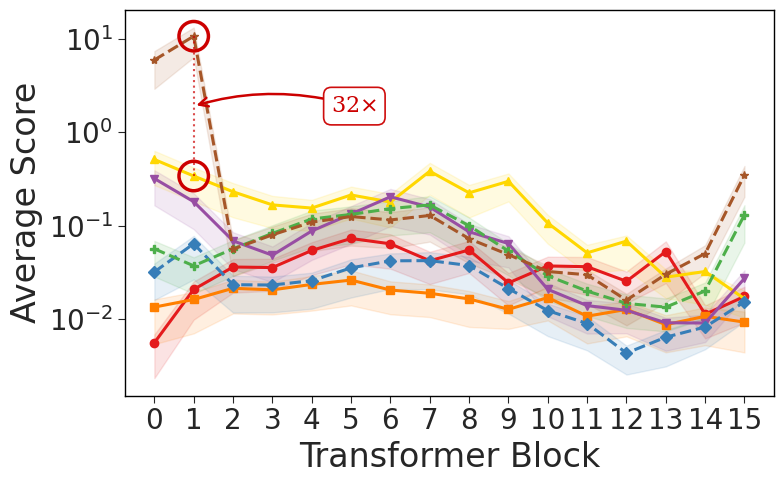

Saved: ./figures/correlation_alpaca_samsum.pdf


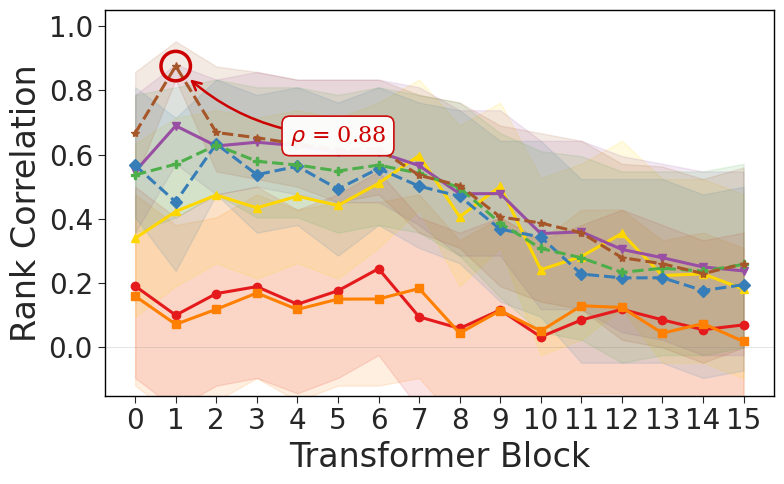

Saved: ./figures/magnitude_less_tydiqa.pdf (2nd largest: V, ratio: 28.9x)


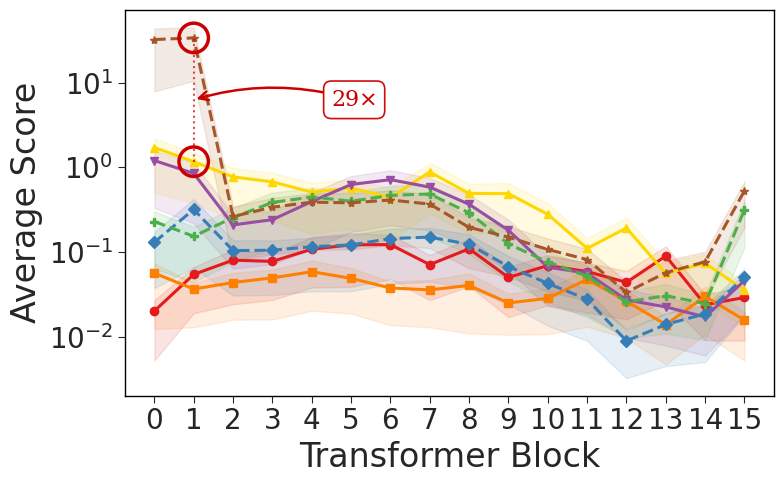

Saved: ./figures/correlation_less_tydiqa.pdf


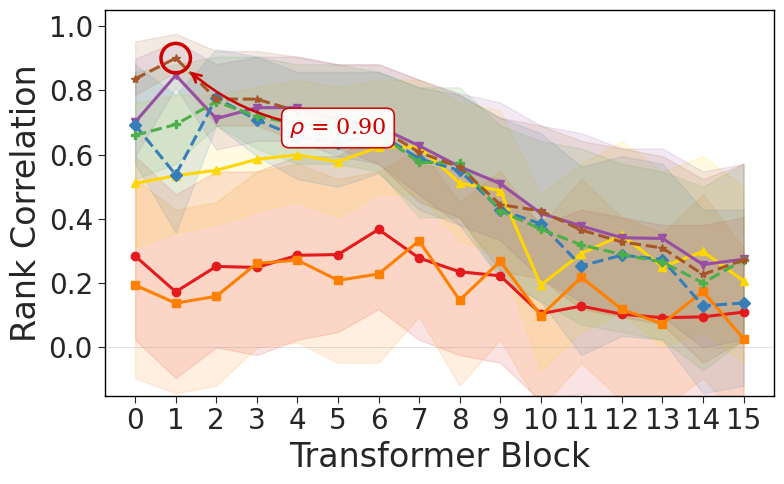

Saved: ./figures/magnitude_triviaqa_nq_open.pdf (2nd largest: V, ratio: 37.5x)


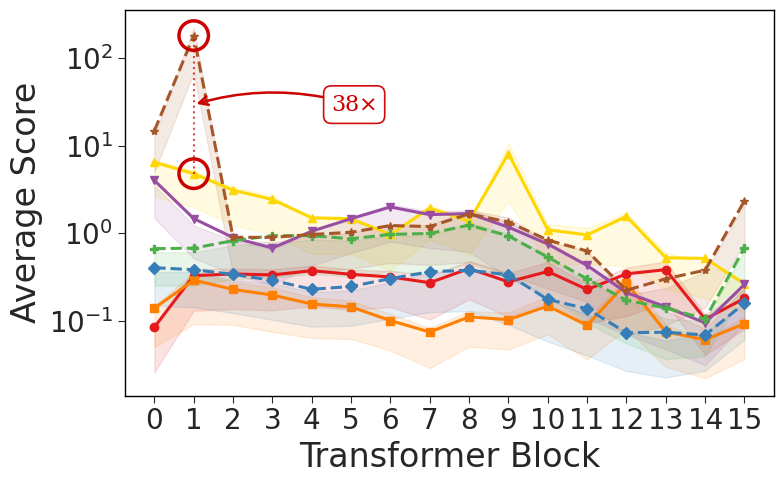

Saved: ./figures/correlation_triviaqa_nq_open.pdf


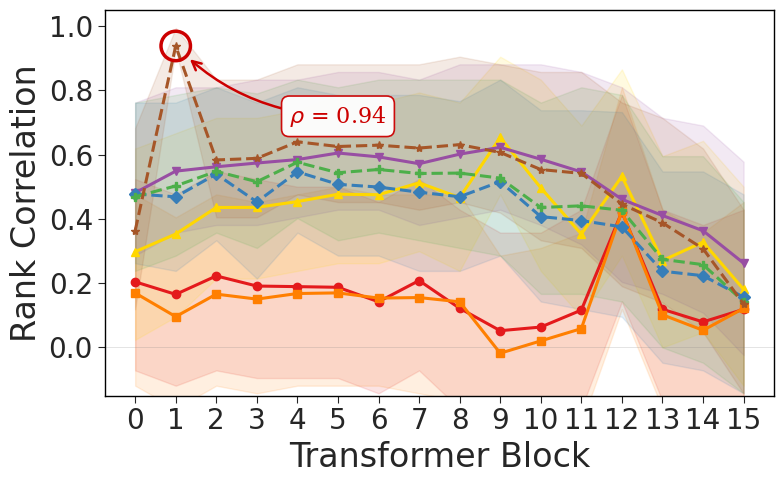

Saved: ./figures/magnitude_less_squad.pdf (2nd largest: V, ratio: 22.1x)


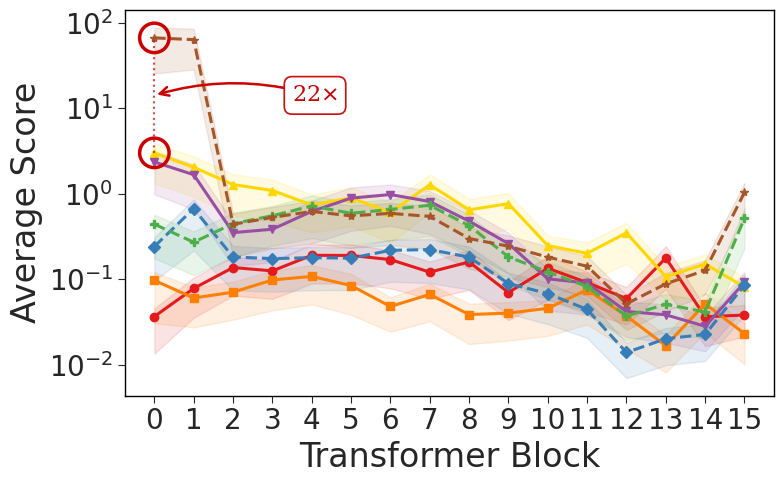

Saved: ./figures/correlation_less_squad.pdf


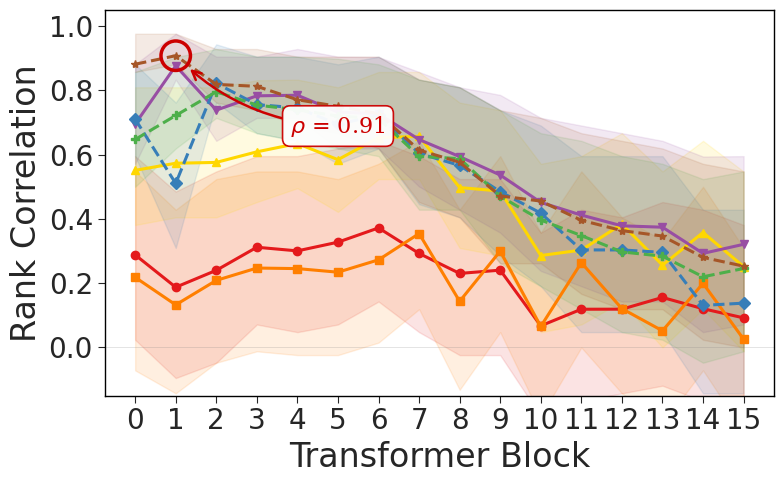

In [5]:
# Publication-quality annotation style
annot_bbox = dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#CC0000', linewidth=1.2, alpha=0.95)
annot_arrow = dict(arrowstyle='->', color='#CC0000', lw=1.8,
                   connectionstyle='arc3,rad=-0.2',
                   shrinkA=0, shrinkB=14)
circle_color = '#CC0000'

for key, res in data.items():
    blocks = list(range(res['num_blocks']))

    # ── Magnitude ──
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    all_type_means = {t: [] for t in LAYER_TYPES}
    for t in LAYER_TYPES:
        means, lo, hi = [], [], []
        for b in blocks:
            vals = res['block_type_abs'][b][t]
            if vals:
                means.append(np.mean(vals))
                lo.append(np.percentile(vals, 25))
                hi.append(np.percentile(vals, 75))
            else:
                means.append(0); lo.append(0); hi.append(0)
        all_type_means[t] = means
        ls = '-' if t in attn_markers else '--'
        ax.plot(blocks, means, color=type_colors[t], linewidth=2.2,
                marker=all_markers[t], markersize=6, linestyle=ls)
        ax.fill_between(blocks, lo, hi, color=type_colors[t], alpha=0.12)

    # Find down_proj peak and second largest type at that block
    down_means = all_type_means['down_proj']
    peak_block = int(np.argmax(down_means))
    peak_val = down_means[peak_block]
    others_at_peak = {t: all_type_means[t][peak_block] for t in LAYER_TYPES if t != 'down_proj'}
    second_type = max(others_at_peak, key=others_at_peak.get)
    second_val = others_at_peak[second_type]
    ratio = peak_val / second_val

    # Red circle on down_proj peak
    ax.scatter([peak_block], [peak_val], s=450, facecolors='none',
               edgecolors=circle_color, linewidths=2.5, zorder=10)
    # Red circle on second largest
    ax.scatter([peak_block], [second_val], s=450, facecolors='none',
               edgecolors=circle_color, linewidths=2.5, zorder=10)
    # Dotted line connecting the two
    ax.plot([peak_block, peak_block], [second_val, peak_val],
            color=circle_color, lw=1.5, ls=':', alpha=0.7, zorder=9)

    # Ratio label at midpoint
    mid_val = np.sqrt(peak_val * second_val)  # geometric mean for log-scale
    ax.annotate(
        f'{ratio:.0f}$\\times$',
        xy=(peak_block, mid_val),
        xytext=(peak_block + 3.5, mid_val),
        fontsize=16, fontfamily='serif',
        color='#CC0000',
        arrowprops=dict(arrowstyle='->', color='#CC0000', lw=1.8,
                        connectionstyle='arc3,rad=0.15',
                        shrinkA=0, shrinkB=2),
        ha='left', va='center',
        bbox=annot_bbox,
    )

    ax.set_xlabel('Transformer Block', fontsize=24)
    ax.set_ylabel('Average Score', fontsize=24)
    ax.set_yscale('log')
    ax.set_xticks(blocks)
    style_ax(ax)

    plt.tight_layout()
    filepath = os.path.join(save_dir, f'magnitude_{key}.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath} (2nd largest: {TYPE_LABELS[second_type]}, ratio: {ratio:.1f}x)')
    plt.show()

    # ── Correlation ──
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    all_type_corr = {t: [] for t in LAYER_TYPES}
    for t in LAYER_TYPES:
        means, lo, hi = [], [], []
        for b in blocks:
            vals = res['block_type_spearman'][b][t]
            if vals:
                means.append(np.mean(vals))
                lo.append(np.percentile(vals, 25))
                hi.append(np.percentile(vals, 75))
            else:
                means.append(0); lo.append(0); hi.append(0)
        all_type_corr[t] = means
        ls = '-' if t in attn_markers else '--'
        ax.plot(blocks, means, color=type_colors[t], linewidth=2.2,
                marker=all_markers[t], markersize=6, linestyle=ls)
        ax.fill_between(blocks, lo, hi, color=type_colors[t], alpha=0.12)

    # Annotate down_proj peak
    down_corr = all_type_corr['down_proj']
    peak_block = int(np.argmax(down_corr))
    peak_val = down_corr[peak_block]

    ax.scatter([peak_block], [peak_val], s=450, facecolors='none',
               edgecolors=circle_color, linewidths=2.5, zorder=10)

    ax.annotate(
        f'$\\rho$ = {peak_val:.2f}',
        xy=(peak_block, peak_val),
        xytext=(peak_block + 4, peak_val - 0.18),
        fontsize=16, fontfamily='serif',
        color='#CC0000',
        arrowprops=annot_arrow,
        ha='center', va='top',
        bbox=annot_bbox,
    )

    ax.set_xlabel('Transformer Block', fontsize=24)
    ax.set_ylabel('Rank Correlation', fontsize=24)
    ax.set_xticks(blocks)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    style_ax(ax)

    plt.tight_layout()
    filepath = os.path.join(save_dir, f'correlation_{key}.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath}')
    plt.show()

## Standalone legend

Saved legend: ./figures/legend.pdf


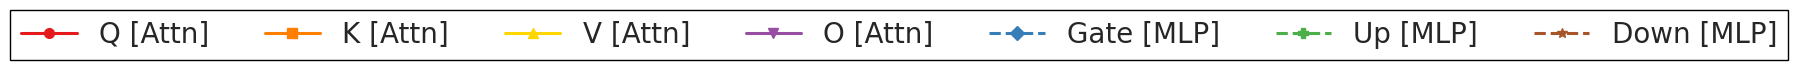

In [6]:
fig_leg, ax_leg = plt.subplots(figsize=(10, 0.6))
ax_leg.set_axis_off()
fig_leg.patch.set_facecolor('white')

handles = []
labels = []
for t in LAYER_TYPES:
    ls = '-' if t in attn_markers else '--'
    h = plt.Line2D([0], [0], color=type_colors[t], linewidth=2.2,
                    marker=all_markers[t], markersize=7, linestyle=ls)
    group = '[Attn]' if t in attn_markers else '[MLP]'
    handles.append(h)
    labels.append(f'{TYPE_LABELS[t]} {group}')

legend = fig_leg.legend(handles, labels, loc='center', ncol=len(LAYER_TYPES),
                        fontsize=20, frameon=True, edgecolor='black',
                        fancybox=False, framealpha=1.0, facecolor='white')
legend.get_frame().set_linewidth(1.0)

filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f'Saved legend: {filepath}')
plt.show()

## Summary statistics

In [7]:
for key, res in data.items():
    print(f'\n{"=" * 60}')
    print(f'  {key} ({res["n_steps"]} steps, batch={res["batch_size"]})')
    print(f'{"=" * 60}')

    # Type-averaged magnitude
    print(f'\n  Score magnitude (mean |score| across all blocks):')
    type_means = {}
    for t in LAYER_TYPES:
        all_vals = []
        for b in range(res['num_blocks']):
            all_vals.extend(res['block_type_abs'][b][t])
        type_means[t] = np.mean(all_vals) if all_vals else 0
    down_mean = type_means['down_proj']
    for t in LAYER_TYPES:
        ratio = down_mean / type_means[t] if type_means[t] > 0 else 0
        print(f'    {TYPE_LABELS[t]:<6s}: {type_means[t]:.6f}  (Down is {ratio:.0f}x larger)')

    # Type-averaged Spearman with GlobalSubset
    print(f'\n  Spearman with GlobalSubset (mean across all blocks):')
    for t in LAYER_TYPES:
        all_vals = []
        for b in range(res['num_blocks']):
            all_vals.extend(res['block_type_spearman'][b][t])
        m = np.mean(all_vals) if all_vals else 0
        print(f'    {TYPE_LABELS[t]:<6s}: {m:.4f}')


  alpaca_samsum (12250 steps, batch=8)

  Score magnitude (mean |score| across all blocks):
    Q     : 0.036730  (Down is 31x larger)
    K     : 0.016038  (Down is 70x larger)
    V     : 0.187773  (Down is 6x larger)
    O     : 0.090036  (Down is 13x larger)
    Gate  : 0.024966  (Down is 45x larger)
    Up    : 0.073716  (Down is 15x larger)
    Down  : 1.127706  (Down is 1x larger)

  Spearman with GlobalSubset (mean across all blocks):
    Q     : 0.1201
    K     : 0.1077
    V     : 0.3820
    O     : 0.4784
    Gate  : 0.4076
    Up    : 0.4368
    Down  : 0.4968

  less_tydiqa (6135 steps, batch=8)

  Score magnitude (mean |score| across all blocks):
    Q     : 0.070642  (Down is 61x larger)
    K     : 0.037170  (Down is 116x larger)
    V     : 0.528057  (Down is 8x larger)
    O     : 0.350250  (Down is 12x larger)
    Gate  : 0.096449  (Down is 45x larger)
    Up    : 0.234979  (Down is 18x larger)
    Down  : 4.328956  (Down is 1x larger)

  Spearman with GlobalSubset